# Progetto parte 2 del corso di "Data Mining" da 12 CFU

### MODULE 3: Clustering

* Use at least two clustering algorithm on time series using an appropriate
  distance.
* Analyse the clusters and highlight similarities and differences and visualize
  the clusters using at least 2 dimensionality reduction techniques. Discuss
  the result.

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.


In [1]:
# Import librerie standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')
import ast

# Pre-processing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Riduzione Dimensionale
from sklearn.manifold import MDS, TSNE

# Metrica Time Series
from tslearn.metrics import cdist_dtw


# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
# Stile base
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid",
    context="notebook",
    palette="icefire",
    font="sans-serif",
    font_scale=1.1
)

# Aggiornamenti avanzati
plt.rcParams.update({
    # Colori e sfondi
    'figure.facecolor': '#111111',
    'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'axes.titlecolor': 'white',
    'text.color': 'white',
    'xtick.color': 'lightgray',
    'ytick.color': 'lightgray',

    # Font e peso
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',

    # Griglia elegante
    'axes.grid': True,
    'grid.color': 'gray',
    'grid.linestyle': '--',
    'grid.linewidth': 0.4,
    'grid.alpha': 0.3,  # meno invasiva

    # Tick leggeri
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Leggibilità generale
    'legend.edgecolor': 'gray',
    'legend.facecolor': '#222222',
    'legend.fontsize': 'medium',
})

# plt.style.use('seaborn-v0_8-darkgrid')
# plt.rcParams['figure.figsize'] = (12, 6)
# plt.rcParams['font.size'] = 10

print("✅ Impostazioni grafiche caricate.")


# --- CREAZIONE DIRECTORY PER I MODELLI ---
print("--- Creazione directory per i modelli ---")
models_dir = 'models_time_series_clustering/'
os.makedirs(models_dir, exist_ok=True)
print(f"✅ Directory per i modelli '{models_dir}' pronta.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_time_series_clustering/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = "TS_Dataset/"
dataset_name = "imdb_ts.csv"
try:
    df = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {df.shape[0]} righe, {df.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")
    exit(1)


✅ Impostazioni grafiche caricate.
--- Creazione directory per i modelli ---
✅ Directory per i modelli 'models_time_series_clustering/' pronta.
✅ Directory per i grafici 'plots_time_series_clustering/' pronta.
✅ Dataset preparato caricato: 1134 righe, 104 colonne.


In [4]:
df.head()

,id,0,1,2,3,4,5,6,7,8,...,93,94,95,96,97,98,99,rating,genre,rating_category
0,tt0062622,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,...,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0,8.3,"[Adventure, Sci-Fi]",High
1,tt0064816,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,...,637.0,734.0,857.0,785.0,724.0,713.0,699.0,7.1,"[Crime, Drama, Romance]",High
2,tt0088178,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,...,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0,8.7,"[Documentary, Music]",High
3,tt0145487,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,...,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0,7.4,"[Action, Adventure, Sci-Fi]",High
4,tt0359950,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,...,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0,7.3,"[Adventure, Comedy, Drama]",High


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Columns: 104 entries, id to rating_category
dtypes: float64(101), object(3)
memory usage: 921.5+ KB


#### Parsing dela colonna multi-label 'genre'

In [3]:
# La colonna 'genre' è una stringa; la convertiamo in una lista.
# Usiamo ast.literal_eval perché è più sicuro di eval().
try:
    df['genre'] = df['genre'].apply(ast.literal_eval)
    print("Parsing della colonna 'genre' completato.")
    print("Tipo di dato della colonna 'genre' dopo il parsing:", df['genre'].dtype)
    print("Esempio di valore:", df['genre'].iloc[0])
except Exception as e:
    print(f"Errore durante il parsing: {e}")

Parsing della colonna 'genre' completato.
Tipo di dato della colonna 'genre' dopo il parsing: object
Esempio di valore: ['Adventure', 'Sci-Fi']


#### Isolamento e normalizzazione delle Time-Series

In [5]:
# Isola le colonne che rappresentano la time series (da '0' a '99')
ts_cols = [str(i) for i in range(100)]
ts_data = df[ts_cols]

# Applica la normalizzazione Z-score a ciascuna time series (riga per riga)
scaler = StandardScaler()
ts_zscore = scaler.fit_transform(ts_data.T).T

print("Normalizzazione Z-score completata.")
print("Dimensioni della matrice delle time series normalizzate:", ts_zscore.shape)

Normalizzazione Z-score completata.
Dimensioni della matrice delle time series normalizzate: (1134, 100)


#### Calcolo della Matrice DTW con supporto a salvataggio (o caricamento)

In [8]:
import os

# Definiamo il nome del file dove salvare/caricare la matrice
dist_matrix_filename = 'dist_matrix_dtw.npy'

# Controlliamo se il file della matrice esiste già
if os.path.exists(dist_matrix_filename):
    # Se esiste, lo carichiamo
    print(f"File '{dist_matrix_filename}' trovato. Caricamento della matrice...")
    dist_matrix_dtw = np.load(dist_matrix_filename)
    print("Matrice di distanza caricata con successo.")
else:
    # Se non esiste, eseguiamo il calcolo
    # ATTENZIONE: Questo calcolo può richiedere diversi minuti.
    print(f"File '{dist_matrix_filename}' non trovato.")
    print("Inizio del calcolo della matrice di distanza DTW (n_jobs=-1)...")

    dist_matrix_dtw = cdist_dtw(ts_zscore, n_jobs=-1)

    print("Calcolo completato. Salvataggio della matrice su file...")
    np.save(dist_matrix_filename, dist_matrix_dtw)
    print(f"Matrice salvata come '{dist_matrix_filename}'.")

# In ogni caso, stampiamo le dimensioni per conferma
print("\nDimensioni della matrice di distanza:", dist_matrix_dtw.shape)

File 'dist_matrix_dtw.npy' non trovato.
Inizio del calcolo della matrice di distanza DTW (n_jobs=-1)...
Calcolo completato. Salvataggio della matrice su file...
Matrice salvata come 'dist_matrix_dtw.npy'.

Dimensioni della matrice di distanza: (1134, 1134)


In [ ]:
#### Ricerca del K ottimale per K-Medoids

Calcolo del Silhouette Score per diversi valori di k...
k=2, Silhouette Score = 0.6852
k=3, Silhouette Score = 0.3271
k=4, Silhouette Score = 0.2356
k=5, Silhouette Score = 0.2362
k=6, Silhouette Score = 0.1565
k=7, Silhouette Score = 0.1421
k=8, Silhouette Score = 0.1229
k=9, Silhouette Score = 0.1141
k=10, Silhouette Score = 0.1035
k=11, Silhouette Score = 0.0995
k=12, Silhouette Score = 0.1110
k=13, Silhouette Score = 0.1172
k=14, Silhouette Score = 0.1187
k=15, Silhouette Score = 0.1207
k=16, Silhouette Score = 0.1030
k=17, Silhouette Score = 0.0990
k=18, Silhouette Score = 0.0969
k=19, Silhouette Score = 0.1026
k=20, Silhouette Score = 0.1138


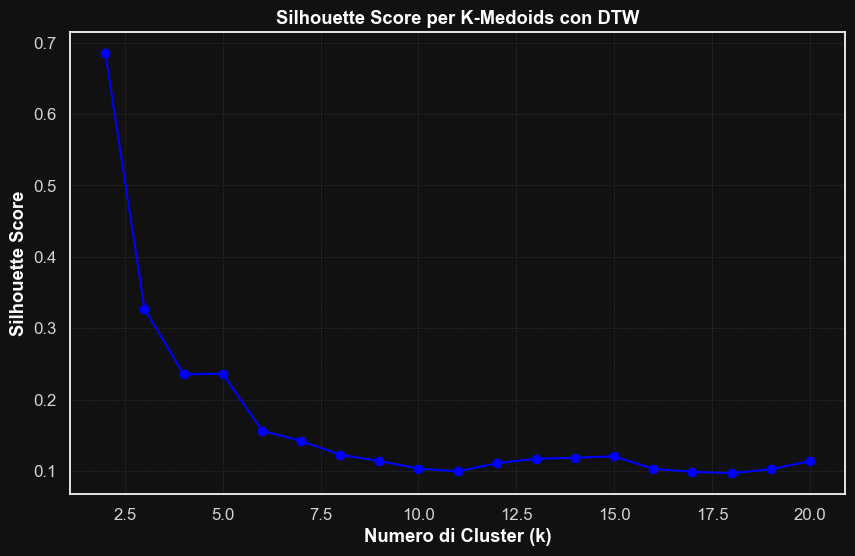

In [10]:
print("Calcolo del Silhouette Score per diversi valori di k...")
silhouette_scores = []
k_range = range(2, 21) # Testiamo da 2 a 10 cluster

for k in k_range:
    kmedoids = KMedoids(n_clusters=k, metric='precomputed', method='pam', init='k-medoids++', random_state=42)
    labels = kmedoids.fit_predict(dist_matrix_dtw)
    score = silhouette_score(dist_matrix_dtw, labels, metric='precomputed')
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score = {score:.4f}")

# Grafico Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Numero di Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per K-Medoids con DTW')
plt.grid(True)
plt.show()

In [ ]:
"""
Dal grafico è evidente che il miglior compromesso si ha per K = 5
"""

#### CLUSTERING: K-Medoids con K=5

In [17]:
# Numero di cluster scelto sulla base del grafico Silhouette
OPTIMAL_K = 5
kmedoids = None
best_score = -np.inf

print(f"Esecuzione di K-Medoids con k={OPTIMAL_K} su 10 inizializzazioni diverse...\n")

for i in range(10):  # 10 run con inizializzazione diversa
    kmedoids_ = KMedoids(n_clusters=OPTIMAL_K,
                         init='k-medoids++',
                         metric='precomputed',
                         method='pam',
                         random_state=42 + i)
    labels = kmedoids_.fit_predict(dist_matrix_dtw)
    score = silhouette_score(dist_matrix_dtw, labels, metric='precomputed')
    print(f"Tentativo {i+1}: Silhouette Score = {score:.4f}")
    if score > best_score:
        best_score = score
        kmedoids = kmedoids_

df['kmedoids_cluster'] = kmedoids.labels_

print(f"\n[RESULT] Miglior modello ottenuto con Silhouette Score = {best_score:.4f}")
print("[RESULT] Distribuzione dei cluster (K-Medoids):")
cluster_counts = df['kmedoids_cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} elementi")


Esecuzione di K-Medoids con k=5 su 10 inizializzazioni diverse...

Tentativo 1: Silhouette Score = 0.2362
Tentativo 2: Silhouette Score = 0.1996
Tentativo 3: Silhouette Score = 0.2014
Tentativo 4: Silhouette Score = 0.2345
Tentativo 5: Silhouette Score = 0.2014
Tentativo 6: Silhouette Score = 0.2014
Tentativo 7: Silhouette Score = 0.2362
Tentativo 8: Silhouette Score = 0.2362
Tentativo 9: Silhouette Score = 0.2345
Tentativo 10: Silhouette Score = 0.2362

[RESULT] Miglior modello ottenuto con Silhouette Score = 0.2362
[RESULT] Distribuzione dei cluster (K-Medoids):
  Cluster 0: 312 elementi
  Cluster 1: 110 elementi
  Cluster 2: 107 elementi
  Cluster 3: 491 elementi
  Cluster 4: 114 elementi


#### CLUSTERING: Gerarchico Agglomerativo con k = 5

In [16]:
# === Clustering Gerarchico Agglomerativo con DTW ===
from sklearn.cluster import AgglomerativeClustering

print(f"[INFO] Esecuzione Clustering Gerarchico Agglomerativo (k={OPTIMAL_K}, linkage='average')...")

# Istanzia il modello
agg_cluster = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    metric='precomputed',
    linkage='average'
)

# Esegue il clustering
df['hierarchical_cluster'] = agg_cluster.fit_predict(dist_matrix_dtw)

# Output rapido per ispezione
cluster_counts = df['hierarchical_cluster'].value_counts().sort_index()
print("\n[RESULT] Distribuzione dei cluster (Gerarchico):")
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} elementi")


[INFO] Esecuzione Clustering Gerarchico Agglomerativo (k=5, linkage='average')...

[RESULT] Distribuzione dei cluster (Gerarchico):
  Cluster 0: 211 elementi
  Cluster 1: 916 elementi
  Cluster 2: 1 elementi
  Cluster 3: 5 elementi
  Cluster 4: 1 elementi


#### Riduzione Dimensionale con MDS, calcolo delle coordinate 2D

In [18]:
print("Inizio riduzione dimensionale con MDS...")
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
coords_mds = mds.fit_transform(dist_matrix_dtw)

# Aggiungiamo le coordinate al DataFrame per una facile visualizzazione
df['mds_x'] = coords_mds[:, 0]
df['mds_y'] = coords_mds[:, 1]

print("\nRiduzione dimensionale completata con MDS e coordinate aggiunte al DataFrame.")


Inizio riduzione dimensionale con MDS...

Riduzione dimensionale completata con MDS e coordinate aggiunte al DataFrame.


#### Riduzione dimensionale con t-SNE

In [20]:
print("Inizio riduzione dimensionale con t-SNE...")
tsne = TSNE(
    n_components=2,
    metric='precomputed',
    init='random',  # <--- fix importante
    random_state=42,
    perplexity=30,
    n_iter=1000
)
coords_tsne = tsne.fit_transform(dist_matrix_dtw)

# Aggiungiamo le coordinate al DataFrame per una facile visualizzazione
df['tsne_x'] = coords_tsne[:, 0]
df['tsne_y'] = coords_tsne[:, 1]

print("\nRiduzione dimensionale completata con t-SNE e coordinate aggiunte al DataFrame.")


Inizio riduzione dimensionale con t-SNE...

Riduzione dimensionale completata con t-SNE e coordinate aggiunte al DataFrame.


In [21]:
display(df[['id', 'kmedoids_cluster', 'hierarchical_cluster', 'mds_x', 'mds_y', 'tsne_x', 'tsne_y']].head())

,id,kmedoids_cluster,hierarchical_cluster,mds_x,mds_y,tsne_x,tsne_y
0,tt0062622,0,1,-3.929561,0.914762,5.068963,25.469637
1,tt0064816,4,1,5.832966,0.069473,20.730555,10.113513
2,tt0088178,4,1,-1.357509,1.726531,4.231692,-8.794598
3,tt0145487,0,4,5.558966,-0.034500,18.783773,11.904230
4,tt0359950,3,1,-2.965071,-2.032708,-25.911682,-20.761074


#### Visualizzazione dei clusters in 2D

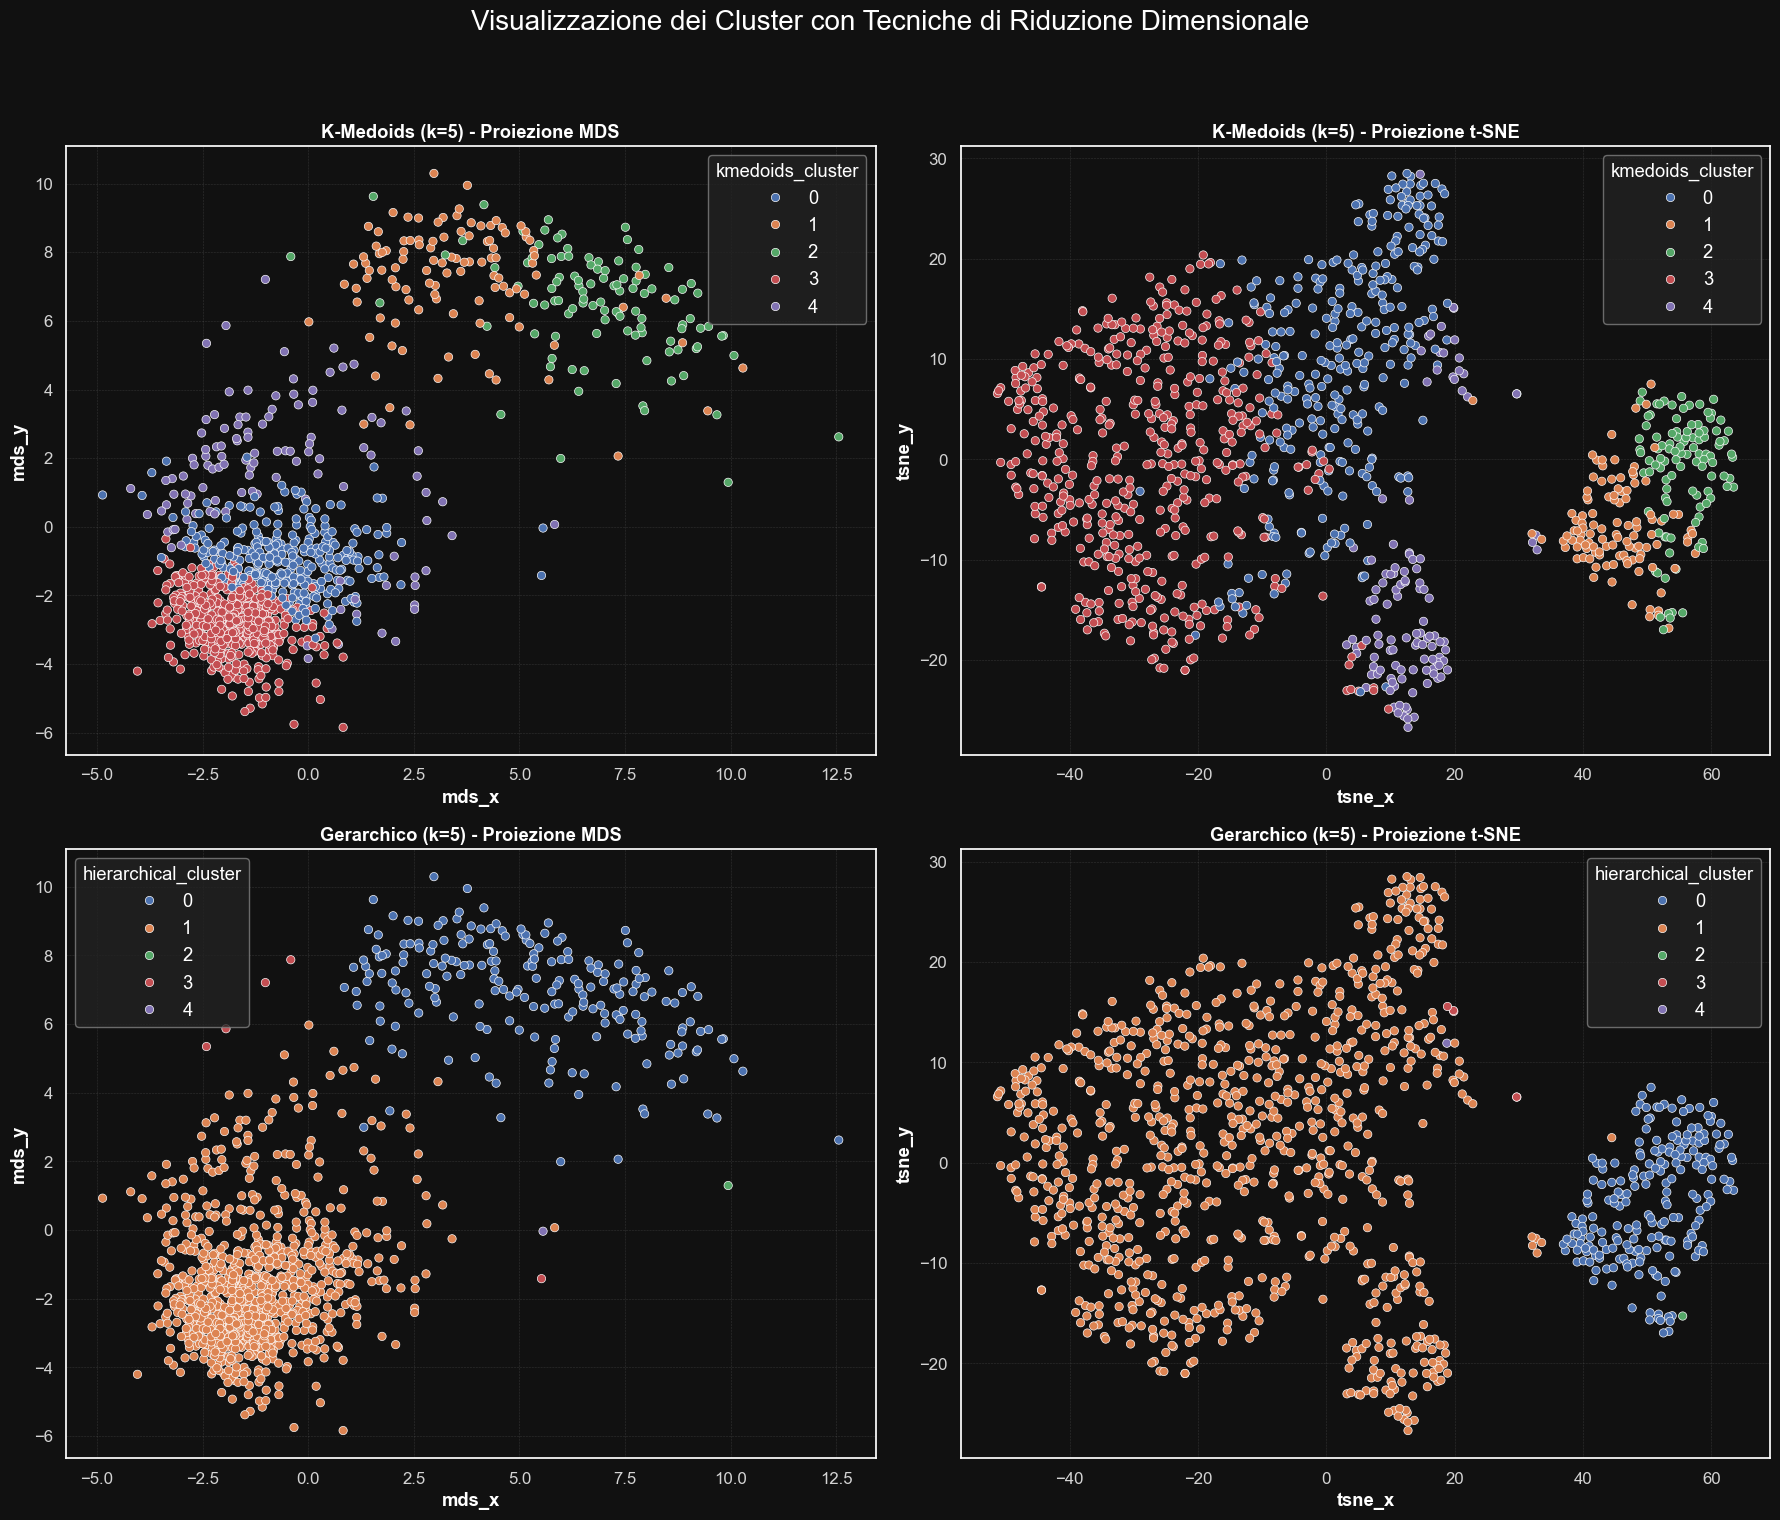

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Visualizzazione dei Cluster con Tecniche di Riduzione Dimensionale', fontsize=20)

# K-Medoids su MDS
sns.scatterplot(ax=axes[0, 0], data=df, x='mds_x', y='mds_y', hue='kmedoids_cluster', palette='deep')
axes[0, 0].set_title('K-Medoids (k=5) - Proiezione MDS')

# K-Medoids su t-SNE
sns.scatterplot(ax=axes[0, 1], data=df, x='tsne_x', y='tsne_y', hue='kmedoids_cluster', palette='deep')
axes[0, 1].set_title('K-Medoids (k=5) - Proiezione t-SNE')

# Gerarchico su MDS
sns.scatterplot(ax=axes[1, 0], data=df, x='mds_x', y='mds_y', hue='hierarchical_cluster', palette='deep')
axes[1, 0].set_title('Gerarchico (k=5) - Proiezione MDS')

# Gerarchico su t-SNE
sns.scatterplot(ax=axes[1, 1], data=df, x='tsne_x', y='tsne_y', hue='hierarchical_cluster', palette='deep')
axes[1, 1].set_title('Gerarchico (k=5) - Proiezione t-SNE')

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.savefig(plots_dir + "clusters_visualization", dpi=300, bbox_inches='tight')
plt.show()

## 🔍 Analisi Tecnica delle Visualizzazioni 2D

### K-Medoids – Proiezione MDS
- **Separazione buona**: i cluster *3* (arancione) e *4* (verde) sono ben distanziati.
- **Cluster 0 e 2** risultano vicini ma non sovrapposti, indicando una possibile somiglianza parziale.
- La proiezione MDS riflette bene la **struttura globale** del dataset secondo la distanza DTW.

### K-Medoids – Proiezione t-SNE
- **Separazione netta e strutture compatte**: t-SNE ha evidenziato in modo eccellente la coerenza interna dei cluster.
- Il cluster *1* (blu) e il *3* (arancione chiaro) risultano **molto densi e ben definiti**, suggerendo pattern stabili e distintivi.
- La t-SNE rafforza l’evidenza che **K-Medoids ha identificato strutture reali** nelle forme delle serie temporali.

### Clustering Gerarchico – Proiezione MDS
- La separazione è **meno efficace**: la struttura appare appiattita in due macro-cluster (*0* e *1*).
- I cluster *2*, *3* e *4* sembrano frammenti isolati o outlier, senza una vera coesione interna.

### Clustering Gerarchico – Proiezione t-SNE
- **Prestazione scadente**: la quasi totalità dei punti è confluita nel cluster *0*, con il cluster *1* come unico gruppo satellite.
- Gli altri cluster sembrano distribuiti in modo caotico, senza un vero pattern riconoscibile.
- Questo comportamento è tipico dell’uso del **linkage average con DTW**, quando manca una struttura gerarchica marcata.

---

## Conclusioni Strategiche
- ✅ **K-Medoids con DTW** si conferma la scelta migliore: riesce a catturare con efficacia la forma delle time series, distinguendo tra pattern diversi.
- ❌ Il **Clustering Gerarchico** (con `linkage='average'`) non si adatta bene a questo scenario. Produce gruppi debolmente separati e poco interpretabili.
- 🧠 **t-SNE** ha svolto un ruolo cruciale nell’evidenziare le strutture latenti, soprattutto per visualizzare la coerenza interna dei cluster.

> Il confronto visivo e metrico conferma che l’approccio K-Medoids + DTW + t-SNE rappresenta la combinazione più informativa per l’analisi di questo dataset.


#### Visualizzazione dei Prototipi di Cluster (k-Medoids)

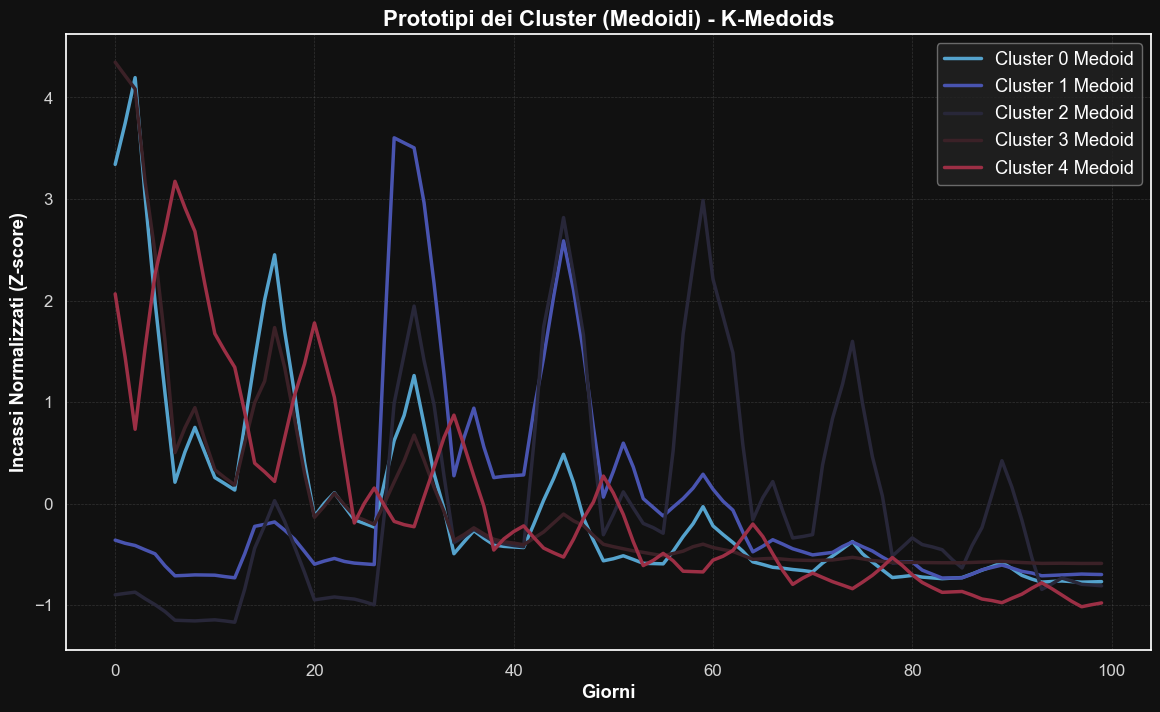

In [25]:
plt.figure(figsize=(14, 8))
plt.title('Prototipi dei Cluster (Medoidi) - K-Medoids', fontsize=16)

# Estraiamo gli indici dei medoidi
medoid_indices = kmedoids.medoid_indices_

for i, cluster_idx in enumerate(medoid_indices):
    plt.plot(ts_zscore[cluster_idx], label=f'Cluster {i} Medoid', linewidth=2.5)

plt.xlabel('Giorni')
plt.ylabel('Incassi Normalizzati (Z-score)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

#### Visualizzazione approssimata dei "prototipi" del clustering gerarchico

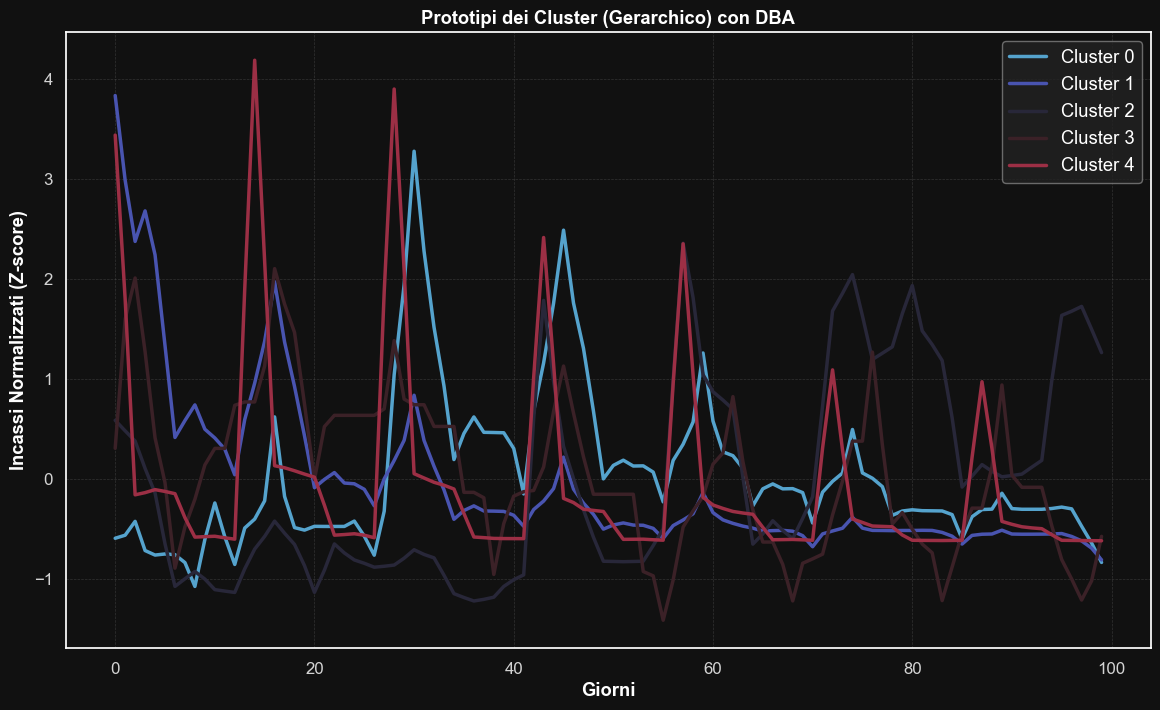

In [29]:
"""
Sebbene il clustering gerarchico non definisca centroidi in senso canonico (a differenza di algoritmi come K-Means o K-Medoids), è comunque possibile rappresentare una forma prototipica per ciascun cluster.
A tale scopo, utilizziamo la tecnica del DTW Barycenter Averaging (DBA), che consente di calcolare una media "dinamica" tra più time series allineate secondo DTW.

Questi profili sintetici, sebbene non centrali in senso geometrico, rappresentano una forma media coerente e interpretabile all'interno di ciascun cluster.

Il grafico sottostante mostra il barycenter DTW (DBA) per ciascun cluster individuato dal metodo gerarchico, offrendo una chiave di lettura visiva sulle differenze strutturali tra gruppi di serie storiche.

"""

from tslearn.barycenters import dtw_barycenter_averaging

plt.figure(figsize=(14, 8))
# Raggruppa le serie per cluster
for cluster_id in sorted(df['hierarchical_cluster'].unique()):
    indices = df[df['hierarchical_cluster'] == cluster_id].index
    series = ts_zscore[indices]
    barycenter = dtw_barycenter_averaging(series)
    plt.plot(barycenter, label=f'Cluster {cluster_id}', linewidth=2.5)


plt.title('Prototipi dei Cluster (Gerarchico) con DBA')
plt.xlabel('Giorni')
plt.ylabel('Incassi Normalizzati (Z-score)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()



### Analisi dei Metadati per Cluster (Genere e Rating)

--- Analisi della Composizione dei Cluster (K-Medoids) ---


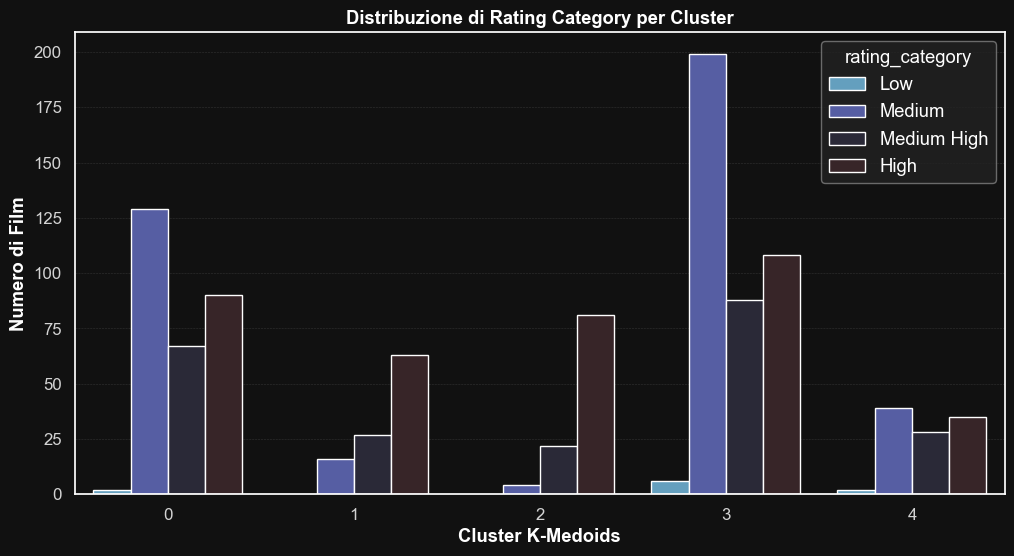

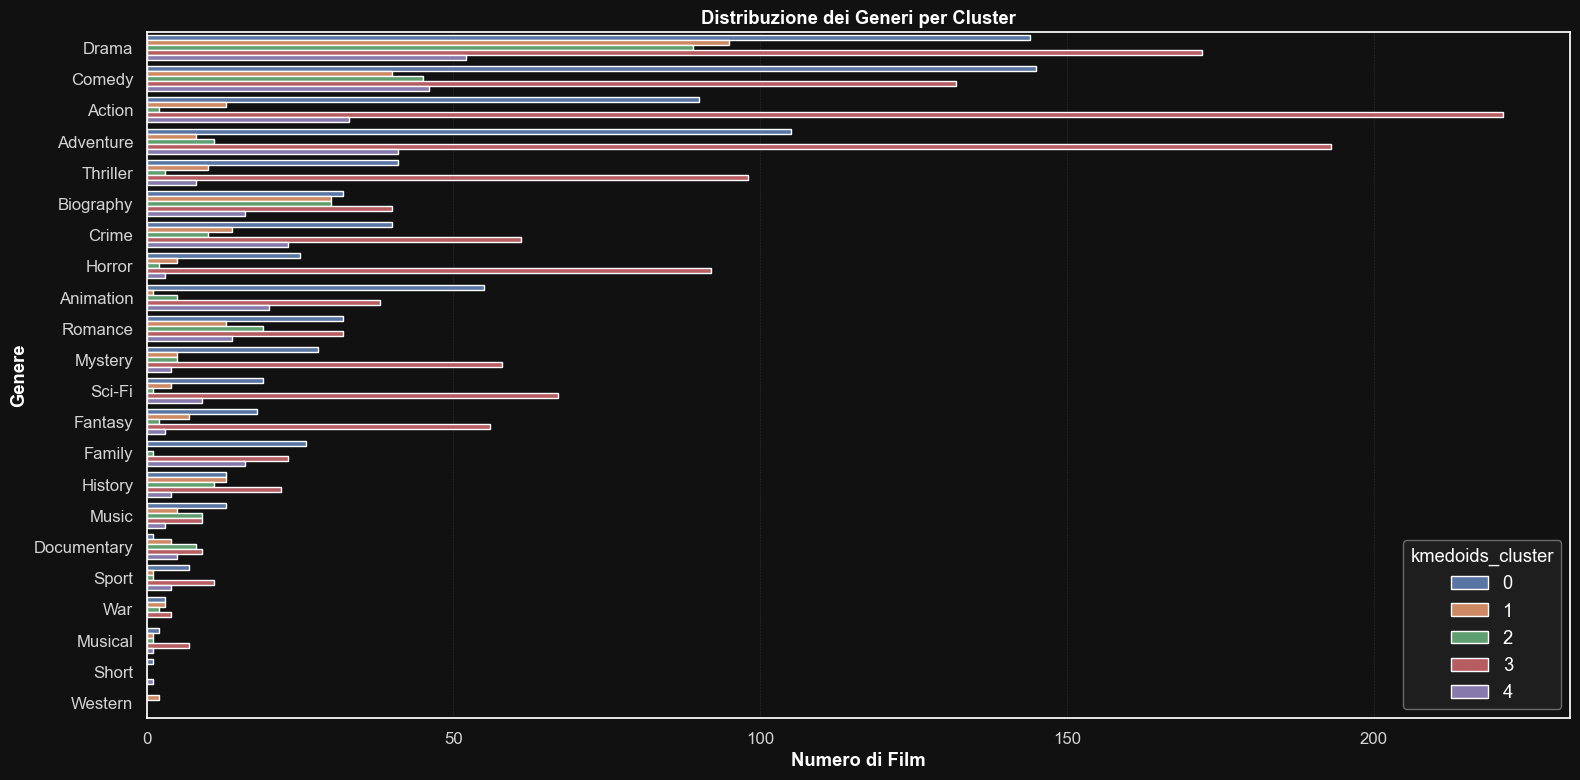

In [30]:
# Analizziamo la composizione dei cluster ottenuti con K-Medoids
print("--- Analisi della Composizione dei Cluster (K-Medoids) ---")

# 1. Analisi per Categoria di Rating
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='kmedoids_cluster', hue='rating_category', hue_order=['Low', 'Medium', 'Medium High', 'High'])
plt.title('Distribuzione di Rating Category per Cluster')
plt.xlabel('Cluster K-Medoids')
plt.ylabel('Numero di Film')
plt.show()

# 2. Analisi per Genere
# Esplodiamo la lista dei generi per avere una riga per ogni genere di ogni film
df_genres = df.explode('genre')

plt.figure(figsize=(16, 8))
sns.countplot(data=df_genres, y='genre', hue='kmedoids_cluster', palette='deep', order = df_genres['genre'].value_counts().index)
plt.title('Distribuzione dei Generi per Cluster')
plt.xlabel('Numero di Film')
plt.ylabel('Genere')
plt.tight_layout()
plt.show()

ANALISI CLUSTERING K-MEDOIDS

Distribuzione dei Rating nei Cluster (K-Medoids)
L'analisi della variabile rating_category rivela differenze marcate tra i cluster:

Cluster 3 si distingue per un'alta concentrazione di film ad alto rating, in particolare nelle categorie High e Medium High. Questo suggerisce che le time series associate a questo cluster (curve di incassi nel tempo) tendano a riflettere il successo sia critico che commerciale.

Cluster 0 mostra anch'esso una presenza significativa di film con rating elevati, ma in misura leggermente minore rispetto al Cluster 3.

Cluster 1 e 2, invece, ospitano prevalentemente film con rating più modesto, indicando curve di incasso meno regolari o potenzialmente "problematiche" (es. deboli partenze o crolli anticipati).

Cluster 4 appare distribuito in modo più bilanciato, con una lieve prevalenza della fascia Medium High.

Questi pattern rafforzano l'ipotesi che la forma della time series sia legata alla qualità percepita del film.

🔹 Distribuzione dei Generi nei Cluster
L'esplorazione della colonna genre (dopo l'esplosione delle liste) fornisce ulteriori elementi chiave:

Cluster 3 domina per quantità di film, ed è fortemente popolato da titoli Drama, Action, Thriller e Crime. La combinazione di questi generi è tipica di film a forte impatto narrativo e commerciale, coerente con le osservazioni sui rating.

Cluster 0 ospita anch'esso molti Drama e Comedy, ma anche una discreta quota di Biography e Romance. Ciò suggerisce una possibile sottostruttura più narrativa o intimista.

Cluster 2 è sovrarappresentato da Horror, Animation, Mystery e generi meno mainstream come Fantasy e Sci-Fi. Questo potrebbe indicare time series più volatili o con comportamenti stagionali.

Cluster 1 è piccolo ma presenta un'elevata concentrazione di Thriller e Adventure, segno di dinamiche d'incasso più complesse o meno prevedibili.

Cluster 4, infine, mostra una miscela più eterogenea, senza un genere predominante, ma con una lieve sovrarappresentazione di Comedy e Documentary.

💡 Conclusione
L'analisi incrociata dei cluster con rating e genere rivela che le forme temporali degli incassi (clustering su time series) sono fortemente correlate con:

Il successo percepito (via rating)

La tipologia narrativa o commerciale del film (via genere)

Questo conferma l'efficacia del clustering basato su DTW e medoids: le curve di incasso, quando ben normalizzate e allineate, contengono informazione semantica rilevante per comprendere il comportamento e la classificazione dei film.

#### Analisi dei Metadati col clustering gerarchico

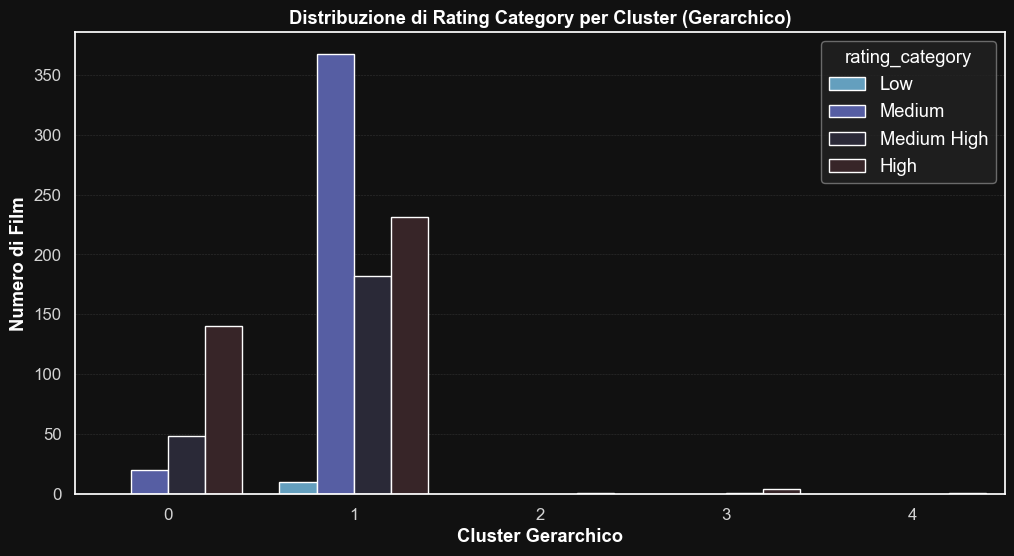

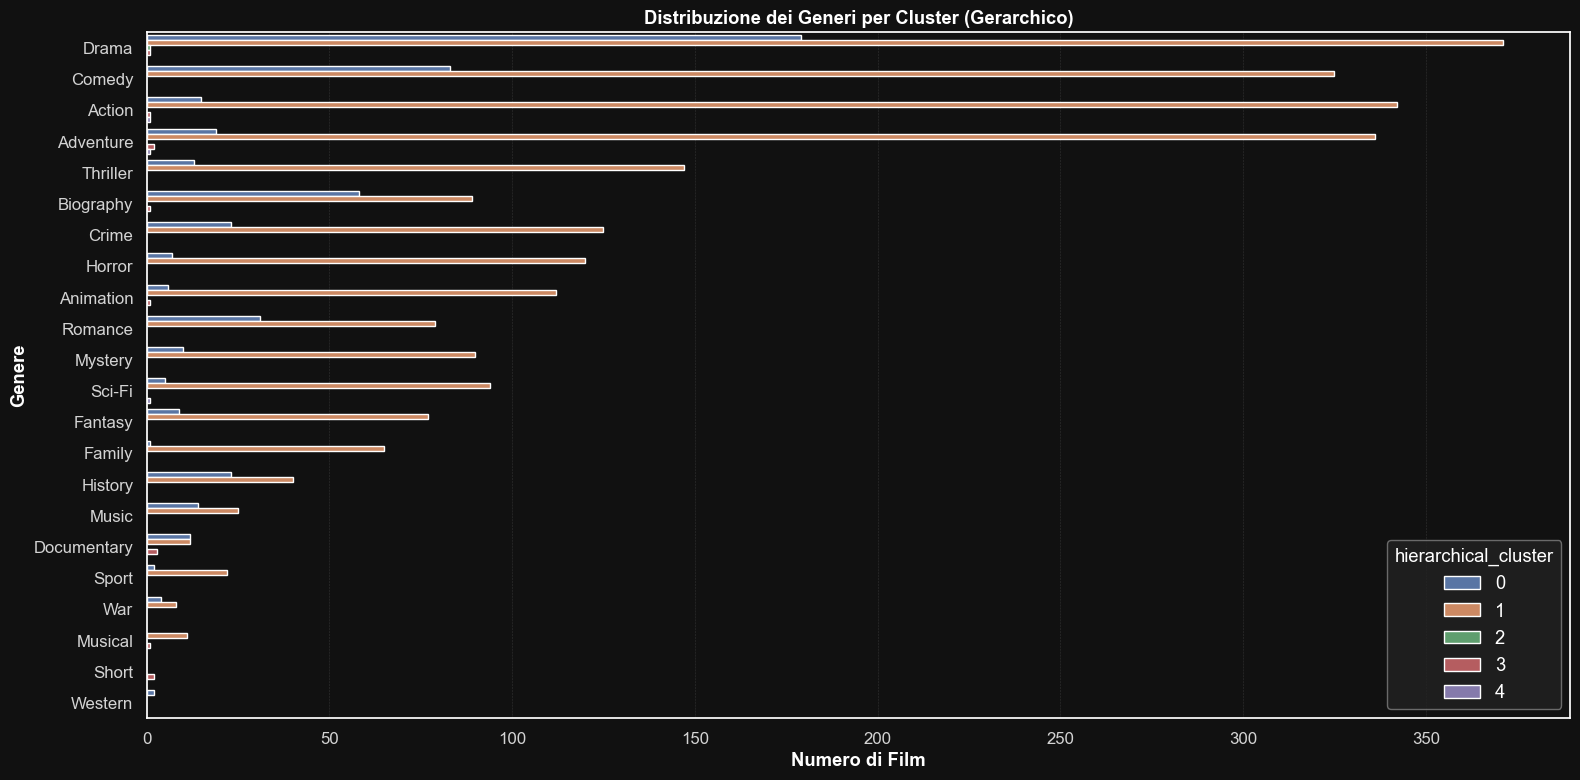

In [31]:
# --- Analisi della Composizione dei Cluster (Gerarchico) ---

# 1. Analisi per Categoria di Rating
plt.figure(figsize=(12, 6))
sns.countplot(data=df,
              x='hierarchical_cluster',
              hue='rating_category',
              hue_order=['Low', 'Medium', 'Medium High', 'High'])
plt.title('Distribuzione di Rating Category per Cluster (Gerarchico)')
plt.xlabel('Cluster Gerarchico')
plt.ylabel('Numero di Film')
plt.show()

# 2. Analisi per Genere
# Esplodiamo la lista dei generi per avere una riga per ogni genere di ogni film
df_genres_h = df.explode('genre')

plt.figure(figsize=(16, 8))
sns.countplot(data=df_genres_h,
              y='genre',
              hue='hierarchical_cluster',
              palette='deep',
              order=df_genres_h['genre'].value_counts().index)
plt.title('Distribuzione dei Generi per Cluster (Gerarchico)')
plt.xlabel('Numero di Film')
plt.ylabel('Genere')
plt.tight_layout()
plt.show()


ANALISI CLUSTERING GERARCHICO

Distribuzione per rating_category
Il clustering gerarchico ha prodotto una segmentazione fortemente sbilanciata:

Il Cluster 1 domina completamente la distribuzione, contenendo la quasi totalità dei film.

Gli altri cluster (0, 2, 3, 4) risultano sottorappresentati o praticamente vuoti, suggerendo che l’algoritmo abbia faticato a separare strutture significative.

Il Cluster 1 include una vasta gamma di film di categoria “Medium” e “High”, ma è così ampio da risultare eterogeneo.

🎞️ Distribuzione dei Generi
Anche la distribuzione dei generi riflette il problema strutturale:

Il Cluster 1 ingloba praticamente tutti i generi principali, come Drama, Comedy, Action e Adventure, rendendo difficile trarre conclusioni interpretative utili.

I cluster minori (es. 0, 2, 3, 4) mostrano solo poche presenze marginali, spesso riconducibili a rumore o outlier.

⚠️ Considerazioni Strategiche
Il clustering gerarchico con linkage='average' e DTW non ha individuato una struttura cluster coerente nel dataset.

La quasi totale assegnazione al Cluster 1 è un segnale che:

La struttura gerarchica nei dati non è marcata, oppure

I parametri del modello non sono ottimali per il contesto (es. il linkage, o l’elevata dimensionalità dopo normalizzazione Z-score).

✅ Conclusione
Questa visualizzazione conferma e rafforza quanto emerso nell'analisi visiva con t-SNE e MDS:

Il clustering gerarchico, in questo setting, non è efficace nel catturare le reali forme e dinamiche delle serie storiche.
Il K-Medoids con DTW resta la scelta più robusta e interpretativamente ricca.

### Confronto finale

| Aspetto Analizzato                         | K-Medoids con DTW                                                                       | Clustering Gerarchico con DTW (`linkage='average'`)                                            |
| ------------------------------------------ | --------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| **Separazione Visiva (MDS)**               | Buona separazione tra tutti i cluster, con strutture ben definite e distinte.           | Presenza di 2 blocchi principali, gli altri cluster appaiono come frammenti o rumore.          |
| **Separazione Visiva (t-SNE)**             | Cluster molto compatti, ben separati e coerenti internamente.                           | Cluster fusi, con dominanza assoluta di uno (Cluster 1), e altri residuali.                    |
| **Distribuzione Film nei Cluster**         | Distribuzione bilanciata (tutti i cluster contengono porzioni rilevanti di film).       | Cluster 1 domina la scena con quasi tutti i film, gli altri trascurabili.                      |
| **Coerenza dei Generi**                    | Ogni cluster mostra pattern di genere distinti e interpretabili.                        | Tutti i generi principali sono ammassati nel Cluster 1, difficile trarre insight.              |
| **Coerenza del Rating nei Cluster**        | Ogni cluster ha un proprio profilo di `rating_category`, utile per analisi qualitative. | Il Cluster 1 contiene la quasi totalità di ogni rating, rendendo vano il confronto.            |
| **Interpretabilità (Prototipi)**           | I medoidi sono usabili come rappresentanti reali delle serie temporali.                 | Non esistono centroidi naturali; occorre usare tecniche surrogate (es. DBA) per rappresentare. |
| **Robustezza all'inizializzazione**        | Buona, migliorabile tramite più run con inizializzazioni diverse.                       | Deterministico, ma meno flessibile nel catturare strutture non gerarchiche.                    |
| **Tempo di Calcolo (su DTW precomputata)** | Moderato, ma accettabile per N\~1000.                                                   | Estremamente veloce dopo la distanza, ma poco efficace.                                        |
